In [1]:
import os
os.listdir('DATASET')

['.ipynb_checkpoints', 'train_1.csv', 'train_images']

In [2]:
import numpy as np
import pandas as pd
import cv2
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [3]:
# 1. Define the correct dataset path
BASE_DIR = 'DATASET/'

In [4]:
# 2. Load the training CSV
df = pd.read_csv(os.path.join(BASE_DIR, 'train_1.csv'))

print("Original Class Distribution:")
print(df['diagnosis'].value_counts().sort_index())

Original Class Distribution:
diagnosis
0    100
1    100
2    100
3    100
4    100
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution'}, xlabel='diagnosis'>

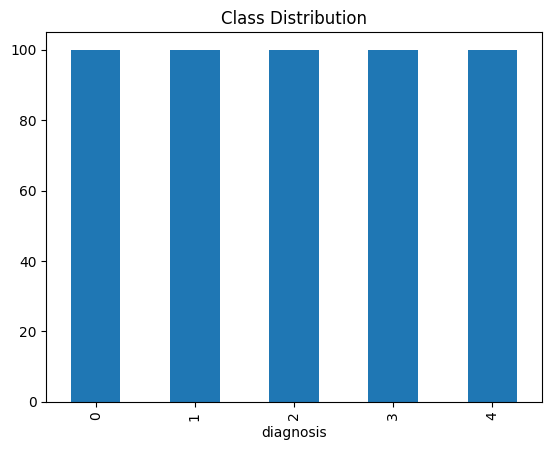

In [5]:
import matplotlib.pyplot as plt
df['diagnosis'].value_counts().sort_index().plot(kind='bar', title='Class Distribution')

In [11]:
# 3. Stratified Split (80% Train, 20% Validation)
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['diagnosis'],
    random_state=42
)

print("\nTraining Set Size:", len(train_df))
print("Validation Set Size:", len(val_df))


Training Set Size: 400
Validation Set Size: 100


Checking path: DATASET/train_images\train_images\364.png
File exists: True


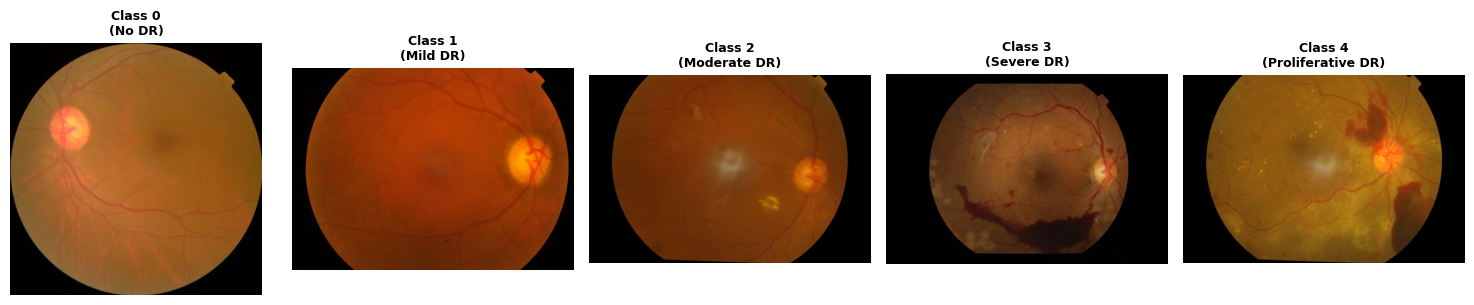


DISPLAYED SAMPLE IMAGES:
Class 0 (No DR          ): 031.png
Class 1 (Mild DR        ): 135.png
Class 2 (Moderate DR    ): 244.png
Class 3 (Severe DR      ): 383.png
Class 4 (Proliferative DR): 445.png


In [12]:
# 4. Create full paths to images
# Note: Pointing to the train_images folder inside BASE_DIR
img_dir = os.path.join(BASE_DIR, 'train_images', 'train_images')

# Safety Check: If the nested folder doesn't exist, use the flat folder
if not os.path.exists(img_dir):
    img_dir = os.path.join(BASE_DIR, 'train_images')

    # Create Path Column
train_df['path'] = train_df['id_code'].apply(lambda x: os.path.join(img_dir, x + '.png'))
val_df['path'] = val_df['id_code'].apply(lambda x: os.path.join(img_dir, x + '.png'))

# Verify that the image is exists or not on that particular path
print("Checking path:", train_df.iloc[0]['path'])
print("File exists:", os.path.exists(train_df.iloc[0]['path']))

# =====================================================
# Display 1 sample image from each class
# =====================================================

import matplotlib.pyplot as plt

# Create a figure with 5 subplots (1 row, 5 columns)
plt.figure(figsize=(15, 3))

# Class names for better visualization
class_names = {
    0: 'No DR',
    1: 'Mild DR',
    2: 'Moderate DR',
    3: 'Severe DR',
    4: 'Proliferative DR'
}

# Loop through each class (0 to 4)
for class_label in range(5):
    # Get 1 random sample from this class
    sample = train_df[train_df['diagnosis'] == class_label].sample(1, random_state=42).iloc[0]
    
    # Read the image using the path column
    img = cv2.imread(sample['path'])
    
    # Convert BGR to RGB (OpenCV loads images in BGR format)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Create subplot
    plt.subplot(1, 5, class_label + 1)
    plt.imshow(img)
    plt.title(f'Class {class_label}\n({class_names[class_label]})', 
              fontweight='bold', fontsize=9)
    plt.axis('off')  # Hide axis

plt.tight_layout()
plt.show()

# Print information about displayed images
print("\n" + "="*60)
print("DISPLAYED SAMPLE IMAGES:")
print("="*50)
for class_label in range(5):
    sample = train_df[train_df['diagnosis'] == class_label].sample(1, random_state=42).iloc[0]
    print(f"Class {class_label} ({class_names[class_label]:15s}): {sample['id_code']}.png")
print("="*60)


In [13]:
def preprocess_dr(path, label):
    # 1. Read
    path = path.numpy().decode()
    img = cv2.imread(path)
    if img is None:
        # for corrupt images
        return np.zeros((224,224,3), dtype=np.float32), label

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Crop Black Borders
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    coords = np.column_stack(np.where(mask))
    if coords.shape[0] > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        img = img[y_min:y_max, x_min:x_max]

    # 3. Resize
    img = cv2.resize(img, (224, 224))

    # 4. CLAHE (Apply to all 3 channels)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    r, g, b = cv2.split(img)
    r = clahe.apply(r)
    g = clahe.apply(g)
    b = clahe.apply(b)
    img = cv2.merge((r, g, b))

    final_img = img.astype(np.float32)

    return final_img, label

def tf_preprocess(path, label):
    img, label = tf.py_function(preprocess_dr, [path, label], [tf.float32, tf.int64])
    img.set_shape((224, 224, 3))
    label.set_shape(())
    return img, label

In [17]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def show_preprocessing(path):
    # -------------------------
    # 1. Load RAW image
    # -------------------------
    raw_img = cv2.imread(path)
    raw_img = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

    # -------------------------
    # 2. Apply SAME preprocessing
    # -------------------------
    img = raw_img.copy()

    # Crop black borders
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray > 10
    coords = np.column_stack(np.where(mask))
    if coords.shape[0] > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        img = img[y_min:y_max, x_min:x_max]

    # Resize
    img = cv2.resize(img, (224, 224))

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    r, g, b = cv2.split(img)
    r = clahe.apply(r)
    g = clahe.apply(g)
    b = clahe.apply(b)
    processed_img = cv2.merge((r, g, b))

    # -------------------------
    # 3. Plot side-by-side
    # -------------------------
    plt.figure(figsize=(10,5))

    # Raw Image
    plt.subplot(1,2,1)
    plt.imshow(raw_img)
    plt.title("Raw Fundus Image", fontweight='bold')
    plt.axis('off')

    # Processed Image
    plt.subplot(1,2,2)
    plt.imshow(processed_img)
    plt.title("CLAHE Enhanced Image", fontweight='bold')
    plt.axis('off')

    plt.suptitle(" Preprocessing Output", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

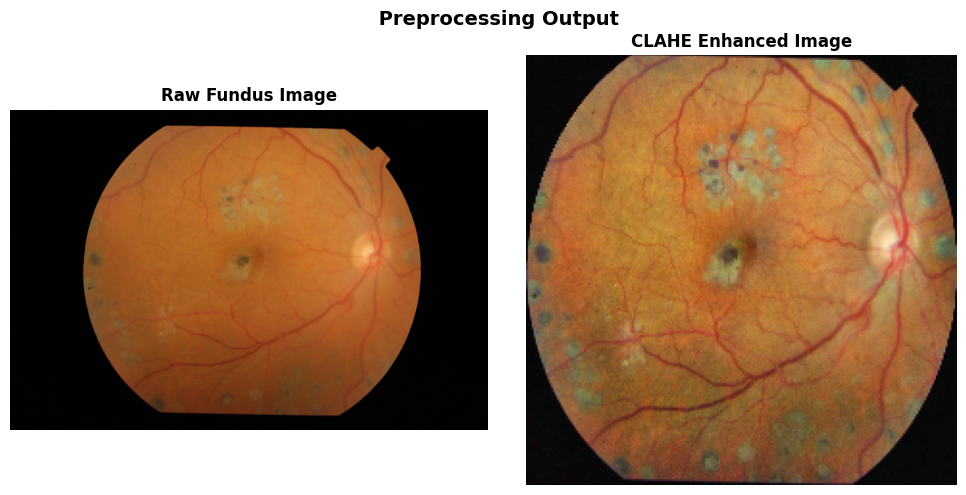

In [18]:
sample_path = train_df.iloc[0]['path']  # or any image path
show_preprocessing(sample_path)

In [23]:
# Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

# Train Dataset
train_ds = tf.data.Dataset.from_tensor_slices((train_df['path'], train_df['diagnosis']))
train_ds = train_ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.cache()
train_ds = train_ds.map(lambda x, y: (data_augmentation(x), y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1024).batch(32).prefetch(tf.data.AUTOTUNE)

# Validation Dataset
val_ds = tf.data.Dataset.from_tensor_slices((val_df['path'], val_df['diagnosis']))
val_ds = val_ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.cache()
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

# Class Weights
classes = np.unique(train_df['diagnosis'])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=train_df['diagnosis'])
class_weights = dict(zip(classes, class_weights))

In [24]:
import tensorflow as tf

# 1. Build Model
effnet_b0 = tf.keras.Sequential([
    tf.keras.applications.EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    ),
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(5, activation='softmax')
])

# 2. UNFREEZE (1-Step Strategy)
effnet_b0.layers[0].trainable = True

# Freeze bottom layers for stability
for layer in effnet_b0.layers[0].layers[:50]:
    layer.trainable = False

# 3. Compile with CORRECT Learning Rate (The Fix)
# Changed from 1e-5 to 1e-4.
# This allows the random Dense layer to learn fast enough.
effnet_b0.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', # Monitor accuracy directly
        patience=7,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# 5. Train
print("Training EfficientNet (1-Step Optimized)...")
history = effnet_b0.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, # 50 is enough with a higher LR
    class_weight=class_weights,
    callbacks=callbacks
)

# Save
effnet_b0.save("effnet_b0_final.keras")

Training EfficientNet (1-Step Optimized)...
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.2750 - loss: 1.5952 - val_accuracy: 0.3200 - val_loss: 1.6470 - learning_rate: 1.0000e-04
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.4200 - loss: 1.3936 - val_accuracy: 0.2500 - val_loss: 1.6443 - learning_rate: 1.0000e-04
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.4950 - loss: 1.2841 - val_accuracy: 0.2500 - val_loss: 1.6320 - learning_rate: 1.0000e-04
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5600 - loss: 1.1840 - val_accuracy: 0.2700 - val_loss: 1.5747 - learning_rate: 1.0000e-04
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.5600 - loss: 1.0906 - val_accuracy: 0.3400 - val_loss: 1.4539 - learning_rate: 1.0000e-04
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6250 - loss: 1.0284 - val_accuracy: 0.4000 - val_loss: 1.3190 - learning_rate: 1.0000e-04
Epoch 7/15
13/13 ━━━━━━━━━━━━━━

In [29]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# 1. Load the trained model
print("Loading model...")
model = tf.keras.models.load_model("effnet_b0_final.keras")

# 2. Define Risk Mapping (EDIT THIS to match your training data)
# Assuming 0 is lowest risk and 4 is highest risk
class_labels = {
    0: "No Risk",
    1: "Low Risk",
    2: "Moderate Risk",
    3: "High Risk",
    4: "Critical Risk"
}

# Color map for risk levels (Green -> Red)
risk_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b']

Loading model...


In [30]:
def predict_risk(image_path, model):
    # 1. Load and Preprocess Image (Must match training input)
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) # Create batch axis
    
    # EfficientNet specific preprocessing
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    # 2. Get Predictions
    predictions = model.predict(img_array, verbose=0)
    probs = predictions[0]
    predicted_class = np.argmax(probs)
    confidence = probs[predicted_class]

    # 3. Map to Risk Level
    risk_level = class_labels[predicted_class]
    
    # 4. Visualize Results
    plt.figure(figsize=(10, 5))
    
    # Plot Image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Prediction: {risk_level}\nConfidence: {confidence:.2%}", fontsize=14, fontweight='bold')
    plt.axis('off')
    
    # Plot Probability Bar Chart
    plt.subplot(1, 2, 2)
    bars = plt.bar(range(5), probs, color=[risk_colors[i] for i in range(5)])
    plt.xticks(range(5), list(class_labels.values()), rotation=45)
    plt.ylim(0, 1)
    plt.ylabel("Probability")
    plt.title("Risk Probability Distribution")
    
    # Highlight the predicted bar
    bars[predicted_class].set_edgecolor('black')
    bars[predicted_class].set_linewidth(2)
    
    plt.tight_layout()
    plt.show()
    
    return predicted_class, confidence

--- Generating Numerical Risk Assessment ---


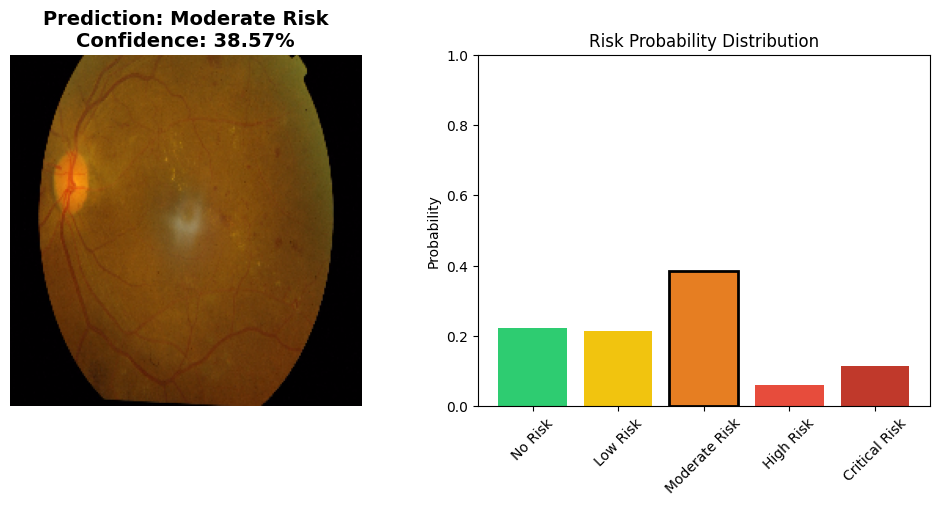

(np.int64(2), np.float32(0.3856937))

In [37]:
# Example Usage
# Replace with the path to a new test image
test_image_path ="C:/Users/DELL 3490/Heart Attack Risk Prediction/42.png" 

print("--- Generating Numerical Risk Assessment ---")
predict_risk(test_image_path, model)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Assuming your model variable is 'effnet_b0' and history is 'history'
# Assuming val_ds is your validation dataset
print("Model Summary:")
effnet_b0.summary()

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,038,216 (45.92 MB)

 Trainable params: 3,991,119 (15.22 MB)

 Non-trainable params: 64,857 (253.35 KB)

 Optimizer params: 7,982,240 (30.45 MB)

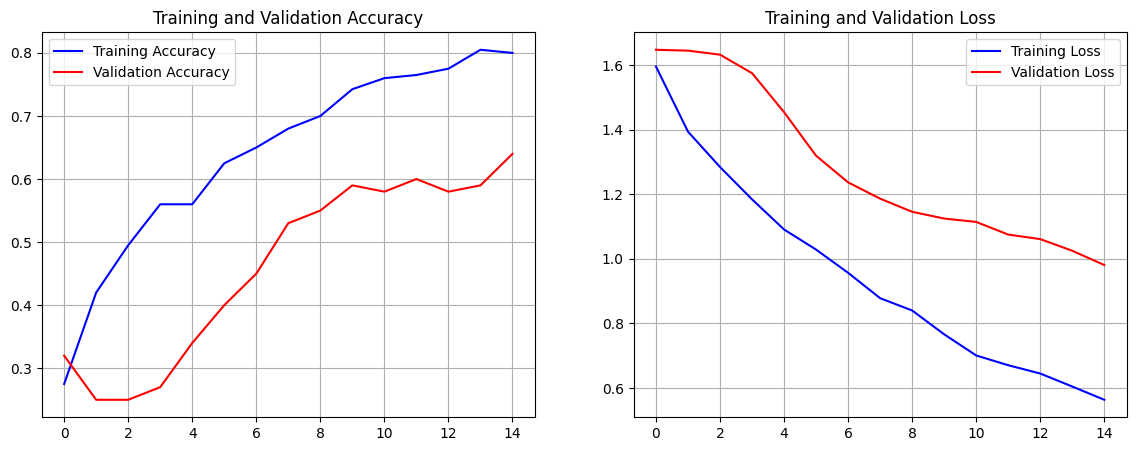

In [39]:
def plot_history(history):
    # Get data from history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(14, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()
    plt.grid(True)

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

# Call the function
plot_history(history)


Generating predictions... please wait.
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step   
Predictions generated successfully.

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.83      0.95      0.88        20
     Class 1       0.58      0.70      0.64        20
     Class 2       0.47      0.45      0.46        20
     Class 3       0.68      0.75      0.71        20
     Class 4       0.58      0.35      0.44        20

    accuracy                           0.64       100
   macro avg       0.63      0.64      0.63       100
weighted avg       0.63      0.64      0.63       100



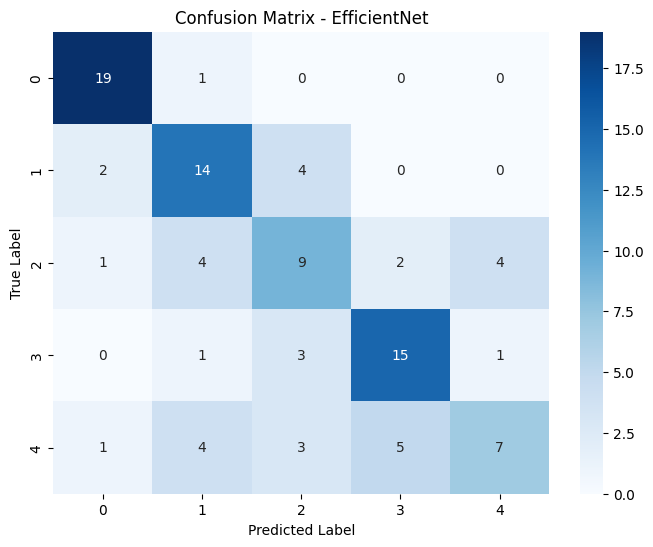

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------------
# STEP 1: CALCULATE PREDICTIONS (Must run this first)
# ---------------------------------------------------------

print("Generating predictions... please wait.")

# 1. Get True Labels from the validation dataset
# We iterate through val_ds to collect all the true labels
y_true = np.concatenate([y.numpy() for x, y in val_ds], axis=0)

# 2. Get Predicted Labels
# We use the model to predict on the validation dataset
y_pred_probs = effnet_b0.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions generated successfully.")

# ---------------------------------------------------------
# STEP 2: PRINT CLASSIFICATION REPORT
# ---------------------------------------------------------

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']))

# ---------------------------------------------------------
# STEP 3: PLOT CONFUSION MATRIX
# ---------------------------------------------------------

def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['0', '1', '2', '3', '4'],
                yticklabels=['0', '1', '2', '3', '4'])

    plt.title('Confusion Matrix - EfficientNet')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(y_true, y_pred)